# Grover's Algorithm: Ideal Simulation

Noiseless PennyLane simulation for $N \in \{4, 8, 16, 32, 64, 256\}$.

$$P(k) = \sin^2\!\bigl((2k+1)\,\theta\bigr), \qquad \theta = \arcsin\!\left(\tfrac{1}{\sqrt{N}}\right), \qquad k_\mathrm{opt} = \left\lfloor\frac{\pi}{4\theta}\right\rfloor$$

In [1]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

sys.path.insert(0, os.path.abspath('../src'))

from grover.grover import optimal_iterations, ideal_success_probability
from noise.amplitude_damping import gamma_from_specs

FIGURES_DIR = '../results/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

/Users/devinlucas/Desktop/CS480A8/CS480A8-Final-Project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Hardware Parameters

In [2]:
hw = pd.read_csv('../data/hardware_specs/hardware_specs.csv')
hw['ratio'] = hw['T1_us'] * 1000 / hw['t_gate_ns']
hw['gamma'] = hw.apply(lambda r: gamma_from_specs(r['T1_us'], r['t_gate_ns']), axis=1)
display(hw[['platform', 'T1_us', 't_gate_ns', 'ratio', 'gamma']])

,platform,T1_us,t_gate_ns,ratio,gamma
0,IBM Quantum (Eagle),100,50,2000.000000,0.000500
1,Google Quantum AI (Sycamore),15,12,1250.000000,0.000800
2,Intel Tunnel Falls (spin),1000,1000,1000.000000,0.001000
3,IonQ Aria (trapped ion),10000000,135000,74074.074074,0.000013


## Ideal Grover Circuit (PennyLane)

In [3]:
def make_ideal_circuit(n_qubits):
    dev = qml.device('default.qubit', wires=n_qubits)

    @qml.qnode(dev)
    def circuit(k):
        for w in range(n_qubits):
            qml.Hadamard(wires=w)
        for _ in range(k):
            qml.FlipSign(0, wires=range(n_qubits))
            qml.GroverOperator(wires=range(n_qubits))
        return qml.probs(wires=range(n_qubits))

    return circuit

## Sweep: $P(\text{success})$ vs. Grover Iterations

In [4]:
N_values = [4, 8, 16, 32, 64, 256]
results = {}

for N in N_values:
    n_qubits = int(np.log2(N))
    k_opt = optimal_iterations(N)
    k_max = 2 * k_opt
    circuit = make_ideal_circuit(n_qubits)

    ks, probs = [], []
    for k in range(k_max + 1):
        p = float(circuit(k)[0])  # all-zeros state is index 0
        ks.append(k)
        probs.append(p)

    results[N] = {'k_opt': k_opt, 'ks': ks, 'probs': probs}
    print(f'N={N:4d}  k_opt={k_opt:3d}  P(k_opt)={probs[k_opt]:.6f}  1/N={1/N:.6f}')

N=   4  k_opt=  1  P(k_opt)=1.000000  1/N=0.250000
N=   8  k_opt=  2  P(k_opt)=0.945312  1/N=0.125000
N=  16  k_opt=  3  P(k_opt)=0.961319  1/N=0.062500
N=  32  k_opt=  4  P(k_opt)=0.999182  1/N=0.031250
N=  64  k_opt=  6  P(k_opt)=0.996586  1/N=0.015625
N= 256  k_opt= 12  P(k_opt)=0.999947  1/N=0.003906


## Cross-Validation: PennyLane vs. Analytic

In [5]:
tol = 1e-9
for N in N_values:
    for k, p_pl in zip(results[N]['ks'], results[N]['probs']):
        p_an = ideal_success_probability(N, k)
        assert abs(p_pl - p_an) < tol, (
            f'N={N}, k={k}: PennyLane={p_pl:.12f}, analytic={p_an:.12f}'
        )
print('PennyLane outputs match analytic formula to < 1e-9 for all (N, k).')

PennyLane outputs match analytic formula to < 1e-9 for all (N, k).


## Plot: $P(\text{success})$ vs. $k$

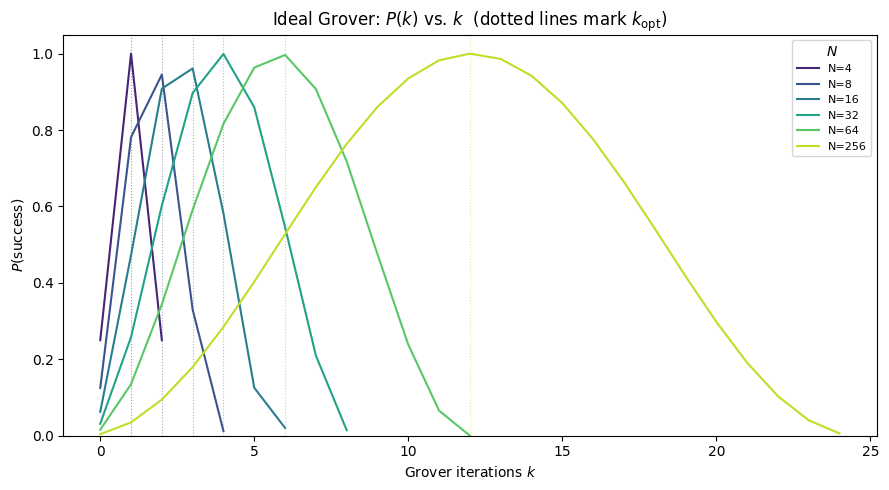

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(N_values)))

for color, N in zip(colors, N_values):
    r = results[N]
    ax.plot(r['ks'], r['probs'], color=color, label=f'N={N}')
    ax.axvline(r['k_opt'], color=color, linestyle=':', linewidth=0.8, alpha=0.5)

ax.set_xlabel('Grover iterations $k$')
ax.set_ylabel('$P(\\mathrm{success})$')
ax.set_title('Ideal Grover: $P(k)$ vs. $k$  (dotted lines mark $k_\\mathrm{opt}$)')
ax.legend(title='$N$', loc='upper right', fontsize=8)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/grover_ideal_sweep.png', dpi=150)
plt.show()